# Explaining Forest Cover Type Predictions with LIME

## Aim

This notebook trains an XGBoost classifier to predict forest cover type from cartographic and environmental measurements, evaluates it on held-out data, and uses **LIME Tabular** to explain individual predictions. It uses one XAI method throughout: LIME’s tabular classifier explainer.

The original Covertype dataset has 581,012 observations, 54 input features, and 7 target classes. To keep training and explanation runs practical on a laptop, the modeling workflow takes a reproducible, stratified sample of 30,000 records from the full dataset.


## 1. Imports and reproducibility

We set fixed random seeds for the data sample, train/test split, XGBoost model, and LIME sampling. The first data-loading run may download the Covertype dataset through scikit-learn if it is not already cached.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_recall_fscore_support
)
from xgboost import XGBClassifier
from lime.lime_tabular import LimeTabularExplainer

RANDOM_STATE = 42
SAMPLE_SIZE = 30_000
plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (9, 5)


## 2. Dataset and prediction objective

The **Covertype** dataset describes forest areas in the Roosevelt National Forest of northern Colorado. Each row represents a 30 × 30 metre cell. The objective is to predict its forest cover type from the cartographic variables. The dataset was assembled for predicting cover type from variables available from a US Geological Survey (USGS) and US Forest Service (USFS) digital map.

### Target classes

The original labels 1–7 identify: Spruce/Fir, Lodgepole Pine, Ponderosa Pine, Cottonwood/Willow, Aspen, Douglas-fir, and Krummholz. The code remaps them to 0–6 for XGBoost while retaining these names in reports and plots.

### Input features

There are 54 features:

| Feature group | Features | What they represent |
|---|---|---|
| Elevation | `Elevation` | Elevation in metres |
| Terrain | `Aspect`, `Slope` | Aspect in degrees azimuth and slope in degrees |
| Hydrology | `Horizontal_Distance_To_Hydrology`, `Vertical_Distance_To_Hydrology` | Horizontal and vertical distance to surface water |
| Access / fire | `Horizontal_Distance_To_Roadways`, `Horizontal_Distance_To_Fire_Points` | Horizontal distance to roads and fire ignition points |
| Hillshade | `Hillshade_9am`, `Hillshade_Noon`, `Hillshade_3pm` | Modelled hillshade at 9 a.m., noon, and 3 p.m. (0–255) |
| Wilderness area | `Wilderness_Area1`–`Wilderness_Area4` | Four binary indicators for wilderness areas |
| Soil type | `Soil_Type1`–`Soil_Type40` | Forty binary indicators for soil types |

The four wilderness indicators and forty soil indicators are one-hot / binary features. Distances and elevation are measured in metres; aspect and slope are angular measurements.


In [5]:
covtype = fetch_covtype()
feature_names = list(covtype.feature_names)
full_y = covtype.target.astype(int) - 1  # original labels 1..7 -> model labels 0..6
class_names = [
    "Spruce/Fir", "Lodgepole Pine", "Ponderosa Pine", "Cottonwood/Willow",
    "Aspen", "Douglas-fir", "Krummholz"
]

# Stratified sample from the full dataset to keep this notebook practical to run.
X_sample, _, y_sample, _ = train_test_split(
    covtype.data, full_y, train_size=SAMPLE_SIZE,
    random_state=RANDOM_STATE, stratify=full_y
)
X = pd.DataFrame(X_sample, columns=feature_names)
y = pd.Series(y_sample, name="cover_type")

print(covtype.DESCR[:1800])
print(f"\nFull dataset rows: {len(covtype.data):,}")
print(f"Modeling sample rows: {len(X):,} | Features: {X.shape[1]} | Classes: {len(class_names)}")
display(X.head())


.. _covtype_dataset:

Forest covertypes
-----------------

The samples in this dataset correspond to 30×30m patches of forest in the US,
collected for the task of predicting each patch's cover type,
i.e. the dominant species of tree.
There are seven covertypes, making this a multiclass classification problem.
Each sample has 54 features, described on the
`dataset's homepage <https://archive.ics.uci.edu/ml/datasets/Covertype>`__.
Some of the features are boolean indicators,
while others are discrete or continuous measurements.

**Data Set Characteristics:**

=================   ============
Classes                        7
Samples total             581012
Dimensionality                54
Features                     int
=================   ============

:func:`sklearn.datasets.fetch_covtype` will load the covertype dataset;
it returns a dictionary-like 'Bunch' object
with the feature matrix in the ``data`` member
and the target values in ``target``. If optional argument 'as_frame' is
se

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area_0,Wilderness_Area_1,Wilderness_Area_2,Wilderness_Area_3,Soil_Type_0,Soil_Type_1,Soil_Type_2,Soil_Type_3,Soil_Type_4,Soil_Type_5,Soil_Type_6,Soil_Type_7,Soil_Type_8,Soil_Type_9,Soil_Type_10,Soil_Type_11,Soil_Type_12,Soil_Type_13,Soil_Type_14,Soil_Type_15,Soil_Type_16,Soil_Type_17,Soil_Type_18,Soil_Type_19,Soil_Type_20,Soil_Type_21,Soil_Type_22,Soil_Type_23,Soil_Type_24,Soil_Type_25,Soil_Type_26,Soil_Type_27,Soil_Type_28,Soil_Type_29,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39
0,2728.0,63.0,3.0,182.0,12.0,1320.0,222.0,233.0,146.0,1947.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3212.0,176.0,10.0,339.0,13.0,3316.0,225.0,246.0,152.0,451.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3217.0,196.0,17.0,771.0,3.0,446.0,213.0,252.0,167.0,2523.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2897.0,93.0,22.0,256.0,92.0,2684.0,248.0,200.0,70.0,1273.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3044.0,47.0,12.0,582.0,190.0,6423.0,224.0,214.0,122.0,3829.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Class counts in the modeling sample

The full dataset is imbalanced: some forest types occur much more often than others. This plot shows class counts in our 30,000-row stratified sample. We also stratify the train/test split so each subset retains similar class proportions.


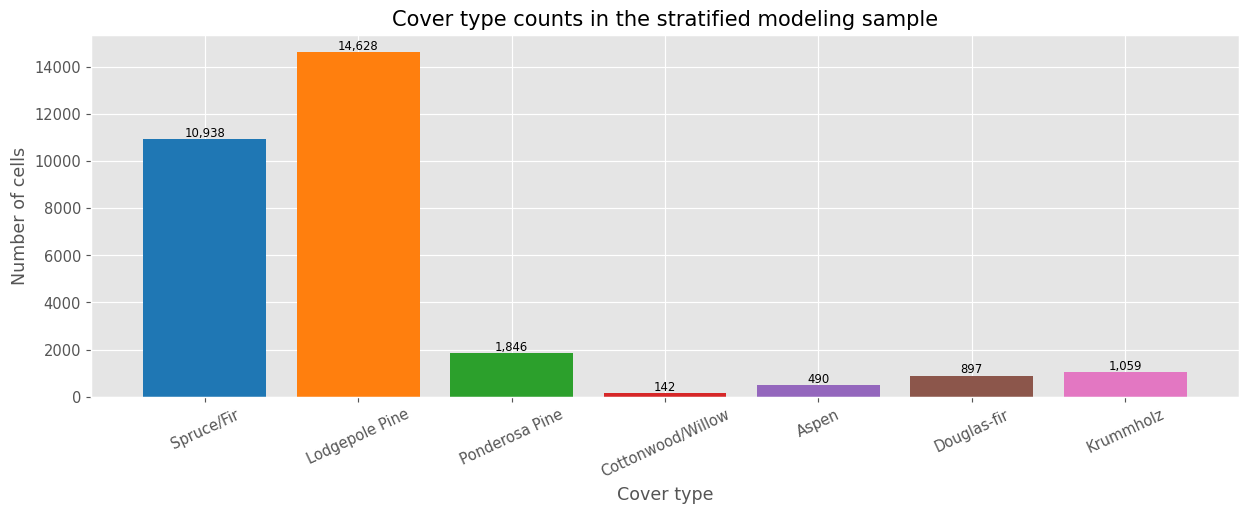

In [7]:
class_counts = y.map(lambda class_id: class_names[class_id]).value_counts().reindex(class_names)
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(class_counts.index, class_counts.values, color=plt.cm.tab10(np.arange(len(class_names))))
ax.set(title="Cover type counts in the stratified modeling sample", xlabel="Cover type", ylabel="Number of cells")
ax.tick_params(axis="x", labelrotation=25)
for bar, value in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 100, f"{value:,}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()


### Continuous feature distributions

The first ten features are continuous measurements and use different scales. We standardize them **for this plot only** so the distributions can be compared; XGBoost is trained on the original values. Boxplots show how these measurements vary across cover types.


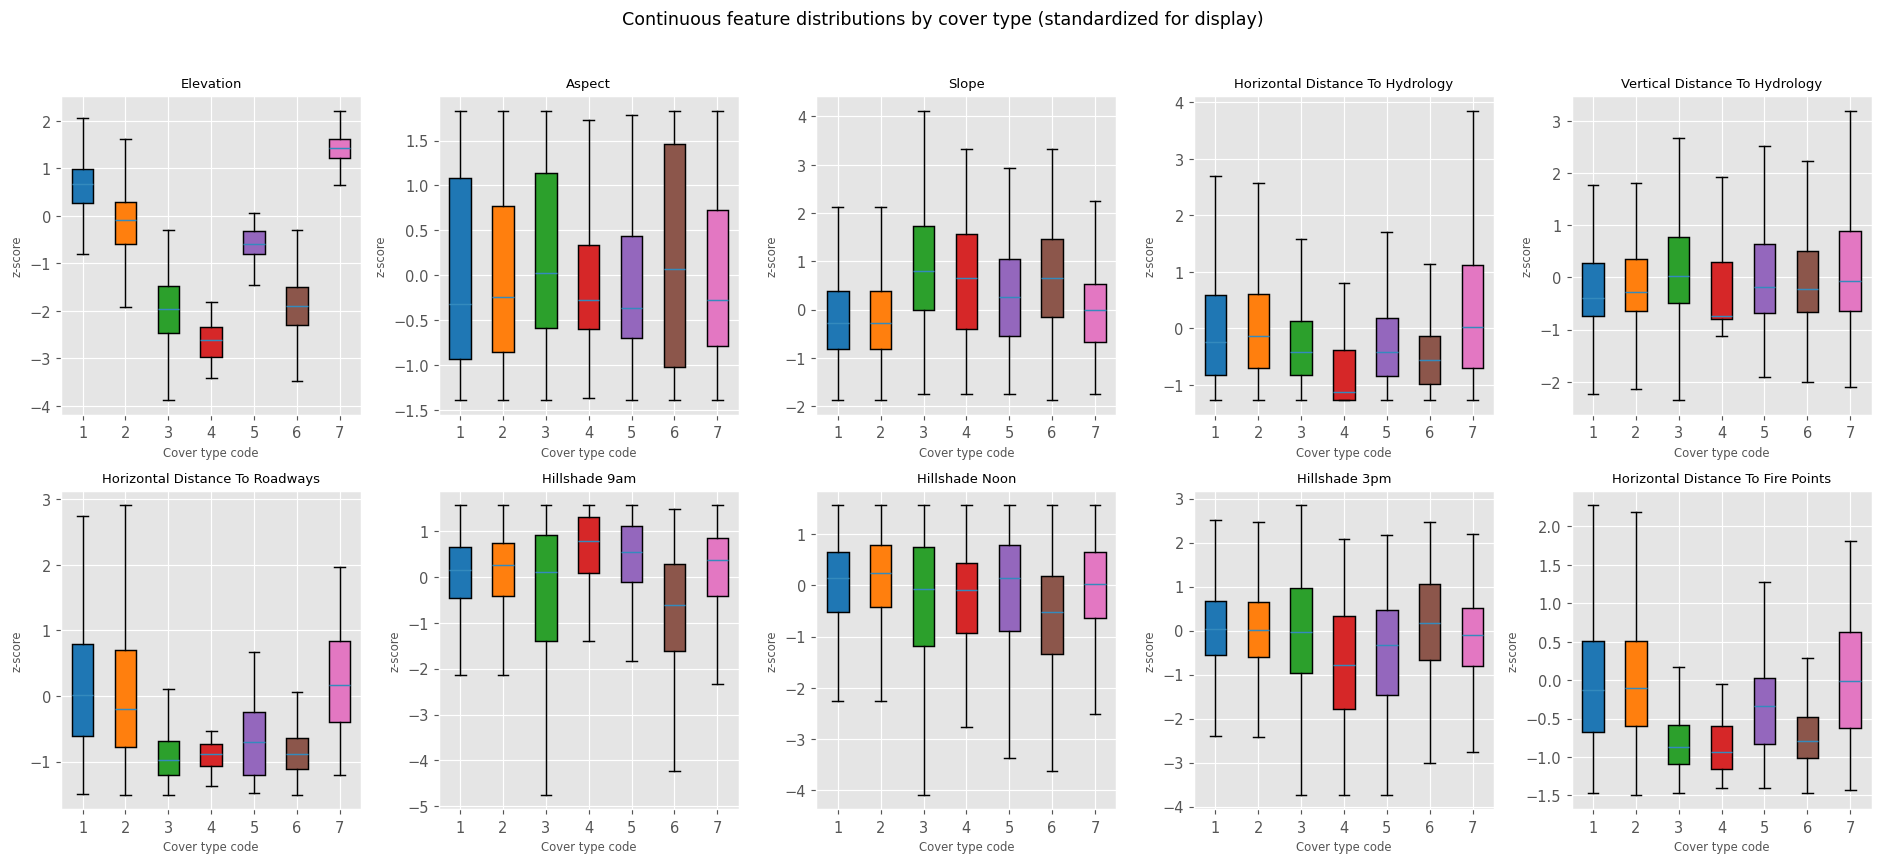

In [9]:
continuous_features = feature_names[:10]
X_cont = X[continuous_features]
z = (X_cont - X_cont.mean()) / X_cont.std(ddof=0)
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
class_colors = plt.cm.tab10(np.arange(len(class_names)))
for ax, feature in zip(axes.flat, continuous_features):
    grouped = [z.loc[y == class_id, feature].to_numpy() for class_id in range(len(class_names))]
    bp = ax.boxplot(grouped, patch_artist=True, showfliers=False)
    for patch, color in zip(bp["boxes"], class_colors):
        patch.set_facecolor(color)
    ax.set_title(feature.replace("_", " "), fontsize=9)
    ax.set_xticks(range(1, len(class_names) + 1), labels=range(1, len(class_names) + 1))
    ax.set_xlabel("Cover type code", fontsize=8)
    ax.set_ylabel("z-score", fontsize=8)
fig.suptitle("Continuous feature distributions by cover type (standardized for display)", y=1.02)
plt.tight_layout()
plt.show()


### Wilderness and soil indicator prevalence

This heatmap shows the share of observations in each cover type with each binary area/soil indicator set to 1. It helps show which soil and wilderness indicators are more common within each class. These are associations in this dataset, not causal effects.


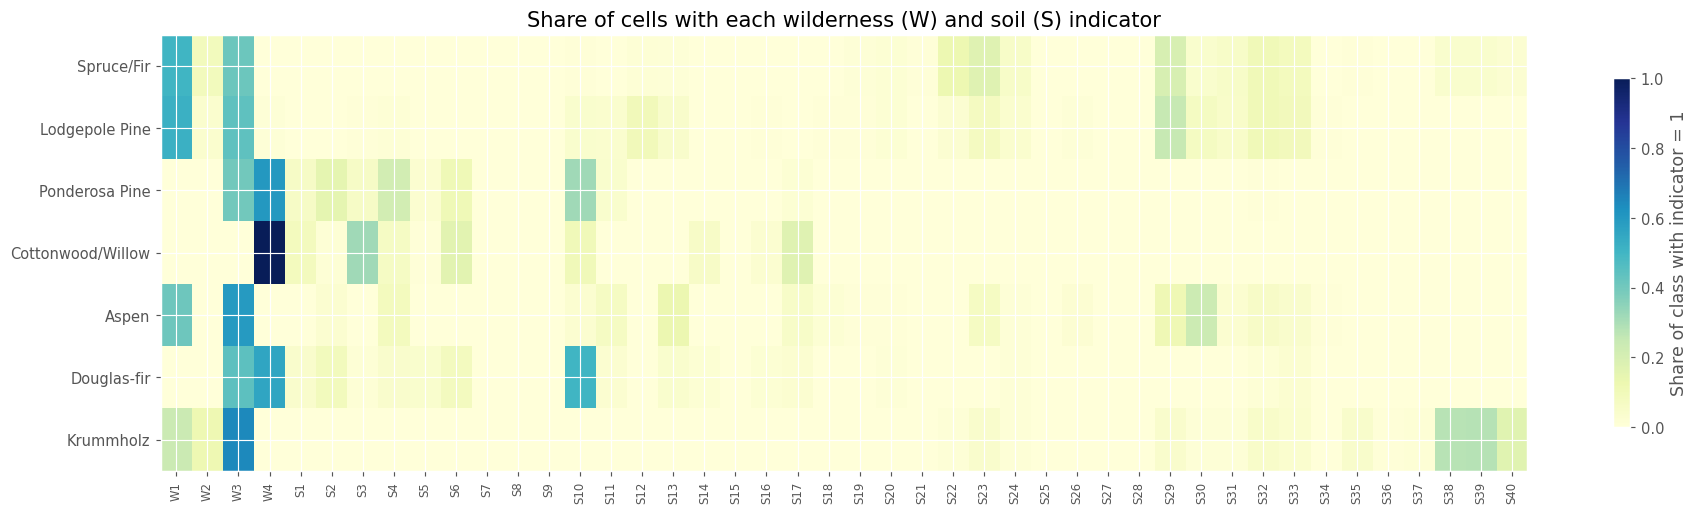

In [11]:
indicator_features = feature_names[10:]
prevalence = X.assign(cover_type=y).groupby("cover_type")[indicator_features].mean().reindex(range(len(class_names)))
fig, ax = plt.subplots(figsize=(18, 5))
image = ax.imshow(prevalence.to_numpy(), aspect="auto", cmap="YlGnBu", vmin=0, vmax=1)
ax.set_yticks(range(len(class_names)), labels=class_names)
short_names = [f"W{i}" for i in range(1, 5)] + [f"S{i}" for i in range(1, 41)]
ax.set_xticks(range(len(indicator_features)), labels=short_names, rotation=90, fontsize=8)
ax.set_title("Share of cells with each wilderness (W) and soil (S) indicator")
fig.colorbar(image, ax=ax, label="Share of class with indicator = 1", shrink=0.8)
plt.tight_layout()
plt.show()


### Pairwise Pearson correlations between continuous features

The heatmap compares the ten continuous measurements pair by pair. Pearson correlation ranges from −1 to +1 and describes linear association. Correlation does not establish causation; the binary soil and wilderness indicators are left out of this particular plot.


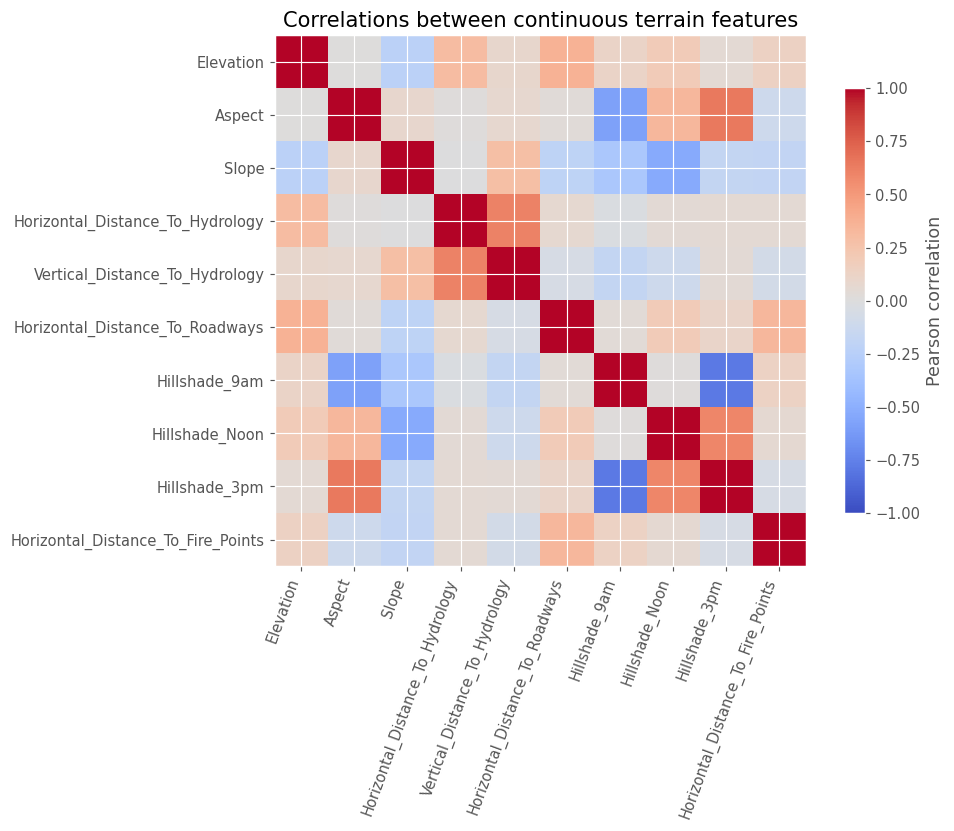

In [13]:
corr = X[continuous_features].corr()
fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)), labels=corr.columns, rotation=70, ha="right")
ax.set_yticks(range(len(corr.index)), labels=corr.index)
fig.colorbar(image, ax=ax, label="Pearson correlation", shrink=0.8)
ax.set_title("Correlations between continuous terrain features")
plt.tight_layout()
plt.show()


## 3. Split the data and train XGBoost

We reserve 25% of the 30,000-row sample as a final test set. XGBoost is a gradient-boosted tree classifier suited to mixed numeric and binary tabular features. LIME is model-agnostic and can explain its class probabilities. The test set is not used to fit the model.


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

model = XGBClassifier(
    n_estimators=250,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=4,
)
model.fit(X_train, y_train)

print(f"Training rows: {len(X_train):,} | Test rows: {len(X_test):,}")
print("Training class proportions:")
print(y_train.value_counts(normalize=True).sort_index().rename(index=dict(enumerate(class_names))).round(3))
print("\nTest class proportions:")
print(y_test.value_counts(normalize=True).sort_index().rename(index=dict(enumerate(class_names))).round(3))


Training rows: 22,500 | Test rows: 7,500
Training class proportions:
cover_type
Spruce/Fir           0.365
Lodgepole Pine       0.488
Ponderosa Pine       0.062
Cottonwood/Willow    0.005
Aspen                0.016
Douglas-fir          0.030
Krummholz            0.035
Name: proportion, dtype: float64

Test class proportions:
cover_type
Spruce/Fir           0.365
Lodgepole Pine       0.488
Ponderosa Pine       0.061
Cottonwood/Willow    0.005
Aspen                0.016
Douglas-fir          0.030
Krummholz            0.035
Name: proportion, dtype: float64


## 4. Check XGBoost general performance

Five-fold cross-validation estimates consistency across several train/validation partitions of the training split. We then report metrics on the untouched test split. Because the classes are imbalanced, inspect precision, recall, and F1 for each class in addition to accuracy. Macro F1 gives each cover type equal weight; weighted F1 reflects class frequency.


In [17]:
model_params = dict(
    n_estimators=250, max_depth=6, learning_rate=0.1,
    subsample=0.9, colsample_bytree=0.9,
    objective="multi:softprob", eval_metric="mlogloss",
    tree_method="hist", random_state=RANDOM_STATE, n_jobs=4,
)
cv_scores = cross_val_score(
    XGBClassifier(**model_params), X_train, y_train, cv=5, scoring="accuracy", n_jobs=1
)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

print(f"5-fold training CV accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Held-out test accuracy:      {accuracy_score(y_test, y_pred):.3f}\n")
print(classification_report(y_test, y_pred, labels=np.arange(len(class_names)), target_names=class_names, digits=3, zero_division=0))


5-fold training CV accuracy: 0.829 ± 0.006
Held-out test accuracy:      0.839

                   precision    recall  f1-score   support

       Spruce/Fir      0.831     0.825     0.828      2734
   Lodgepole Pine      0.845     0.879     0.861      3657
   Ponderosa Pine      0.817     0.850     0.833       461
Cottonwood/Willow      0.871     0.750     0.806        36
            Aspen      0.945     0.423     0.584       123
      Douglas-fir      0.757     0.638     0.692       224
        Krummholz      0.939     0.808     0.868       265

         accuracy                          0.839      7500
        macro avg      0.858     0.739     0.782      7500
     weighted avg      0.840     0.839     0.838      7500



### Confusion matrix

Rows show the true cover type and columns show predictions. The diagonal contains correct classifications. Off-diagonal cells show which forest types the model confused.


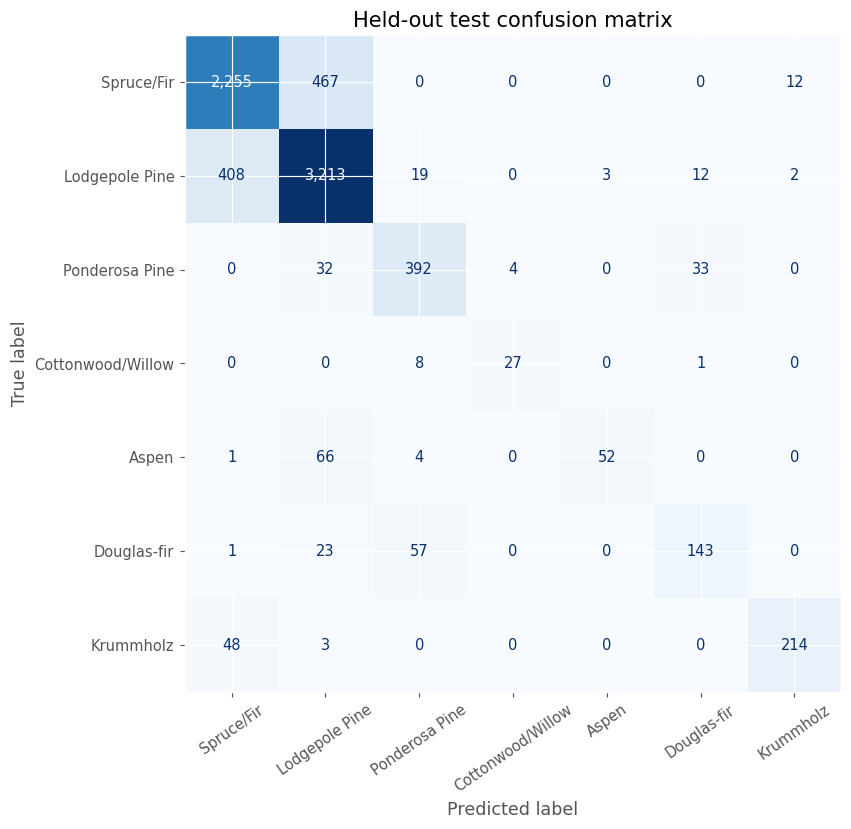

In [19]:
cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(class_names)))
fig, ax = plt.subplots(figsize=(10, 8))
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
cm_display.plot(ax=ax, cmap="Blues", values_format=",d", colorbar=False, xticks_rotation=35)
plt.title("Held-out test confusion matrix")
plt.tight_layout()
plt.show()


### Per-class precision, recall, and F1

This grouped bar chart compares class-wise precision, recall, and F1 on the same held-out predictions. A class with lower recall is often being missed; lower precision means predictions of that class are more often wrong.


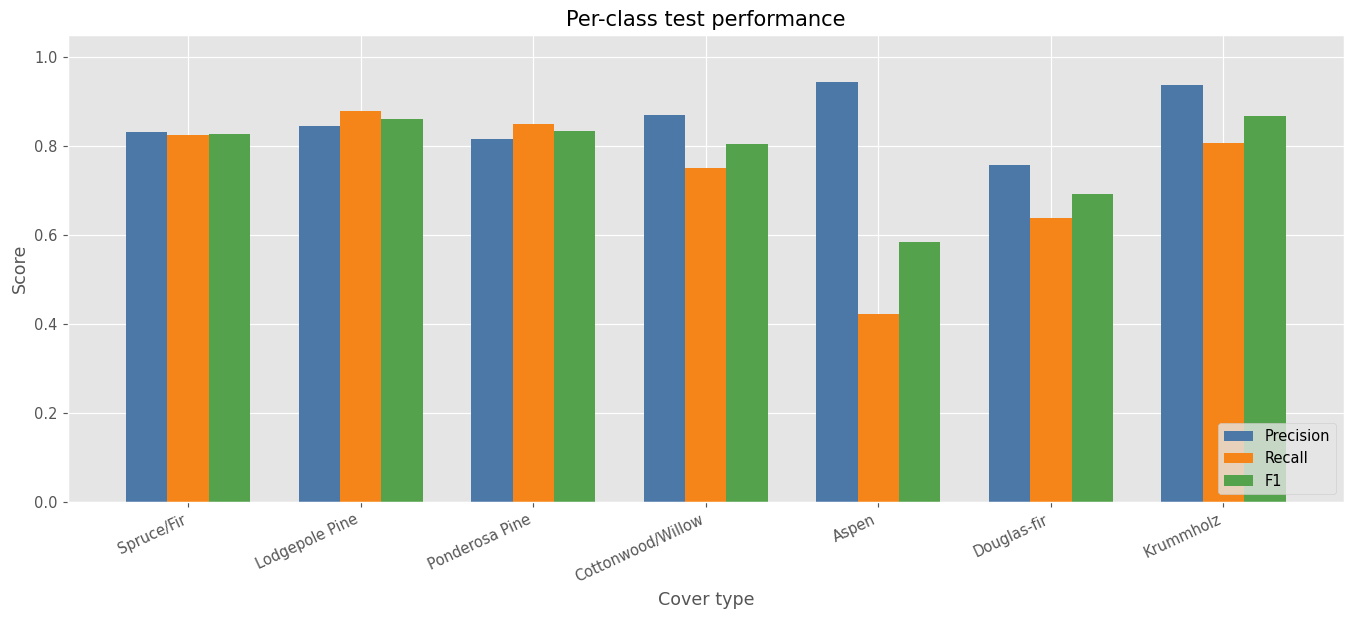

,Precision,Recall,F1
Spruce/Fir,0.831,0.825,0.828
Lodgepole Pine,0.845,0.879,0.861
Ponderosa Pine,0.817,0.850,0.833
Cottonwood/Willow,0.871,0.750,0.806
Aspen,0.945,0.423,0.584
Douglas-fir,0.757,0.638,0.692
Krummholz,0.939,0.808,0.868


In [21]:
precision, recall, f1, support = precision_recall_fscore_support(
    y_test, y_pred, labels=np.arange(len(class_names)), zero_division=0
)
metrics = pd.DataFrame({"Precision": precision, "Recall": recall, "F1": f1}, index=class_names)
fig, ax = plt.subplots(figsize=(13, 6))
positions = np.arange(len(class_names))
width = 0.24
for offset, (metric_name, color) in enumerate(zip(metrics.columns, ["#4C78A8", "#F58518", "#54A24B"])):
    ax.bar(positions + (offset - 1) * width, metrics[metric_name], width, label=metric_name, color=color)
ax.set(title="Per-class test performance", xlabel="Cover type", ylabel="Score", ylim=(0, 1.05))
ax.set_xticks(positions, labels=class_names, rotation=25, ha="right")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()
display(metrics.round(3))


## 5. Configure LIME Tabular

LIME explains one prediction at a time. It creates perturbed versions of an observation, queries XGBoost, and fits a simple local surrogate model. The feature weights describe local associations with the selected class; they are not causal effects or a global summary of XGBoost.

The explainer uses the training data as its reference distribution, with the 54 original feature names. Continuous features are discretized into ranges; the 44 binary indicators are explicitly marked as categorical so LIME can display them as present/absent conditions.


In [23]:
categorical_features = list(range(10, 54))
categorical_names = {i: ["0 (absent)", "1 (present)"] for i in categorical_features}

explainer = LimeTabularExplainer(
    training_data=X_train.to_numpy(),
    feature_names=list(X.columns),
    categorical_features=categorical_features,
    categorical_names=categorical_names,
    class_names=class_names,
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE,
)


## 6. Explain a held-out prediction

We select a correctly classified test observation with high confidence, if one exists. This gives a concrete example of what the model learned. The selected row remains separate from model fitting.


In [25]:
correct_positions = np.flatnonzero(y_pred == y_test.to_numpy())
if len(correct_positions) == 0:
    instance_idx = int(np.argmax(y_proba.max(axis=1)))
else:
    instance_idx = int(correct_positions[np.argmax(y_proba[correct_positions].max(axis=1))])

instance = X_test.iloc[instance_idx].to_numpy()
true_class = int(y_test.iloc[instance_idx])
predicted_class = int(y_pred[instance_idx])
probabilities = y_proba[instance_idx]

print(f"Test row position: {instance_idx}")
print(f"Actual cover type:    {class_names[true_class]}")
print(f"Predicted cover type: {class_names[predicted_class]}")
print("Class probabilities:")
display(pd.Series(probabilities, index=class_names).sort_values(ascending=False).to_frame("probability").round(3))

explanation = explainer.explain_instance(
    data_row=instance,
    predict_fn=model.predict_proba,
    labels=(predicted_class,),
    num_features=10,
    num_samples=4000,
)
print(f"LIME local surrogate R²: {explanation.score:.3f}")
print("\nFeatures and local weights:")
display(pd.DataFrame(explanation.as_list(label=predicted_class), columns=["feature condition", "LIME weight"]).round(3))


Test row position: 4915
Actual cover type:    Lodgepole Pine
Predicted cover type: Lodgepole Pine
Class probabilities:
LIME local surrogate R²: 0.017

Features and local weights:


,probability
Lodgepole Pine,0.999
Spruce/Fir,0.000
Ponderosa Pine,0.000
Aspen,0.000
Krummholz,0.000
Douglas-fir,0.000
Cottonwood/Willow,0.000


,feature condition,LIME weight
0,Soil_Type_33=1 (present),0.301
1,Soil_Type_34=0 (absent),0.284
2,Soil_Type_13=0 (absent),0.275
3,Soil_Type_35=0 (absent),0.214
4,Soil_Type_37=0 (absent),0.207
5,Soil_Type_8=0 (absent),0.165
6,Soil_Type_20=0 (absent),0.162
7,Soil_Type_26=0 (absent),0.159
8,Soil_Type_36=0 (absent),0.156
9,Soil_Type_6=0 (absent),0.155


### Local feature contributions

Positive weights support the selected class in LIME’s local surrogate; negative weights count against it. Continuous-feature conditions show value ranges, while soil and wilderness features may appear as binary conditions. The weights are not changes in XGBoost’s class probability.


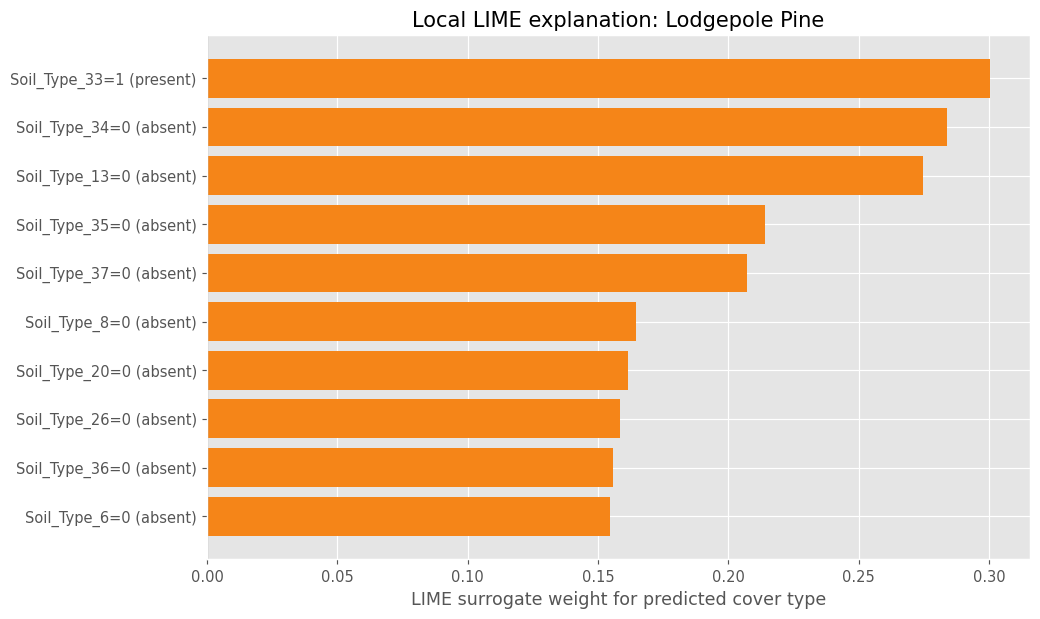

In [27]:
local_terms = explanation.as_list(label=predicted_class)
local_df = pd.DataFrame(local_terms, columns=["condition", "weight"]).sort_values("weight")
colors = ["#4C78A8" if value < 0 else "#F58518" for value in local_df.weight]
plt.figure(figsize=(10, 6))
plt.barh(local_df.condition, local_df.weight, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("LIME surrogate weight for predicted cover type")
plt.title(f"Local LIME explanation: {class_names[predicted_class]}")
plt.tight_layout()
plt.show()


## 7. Compare local explanations for different test examples

A single case can be atypical. We explain one held-out example predicted as each cover type, when examples for that type are available. The predicted class differs between panels, so compare conditions within a panel; do not interpret weight magnitudes across panels as one global ranking.


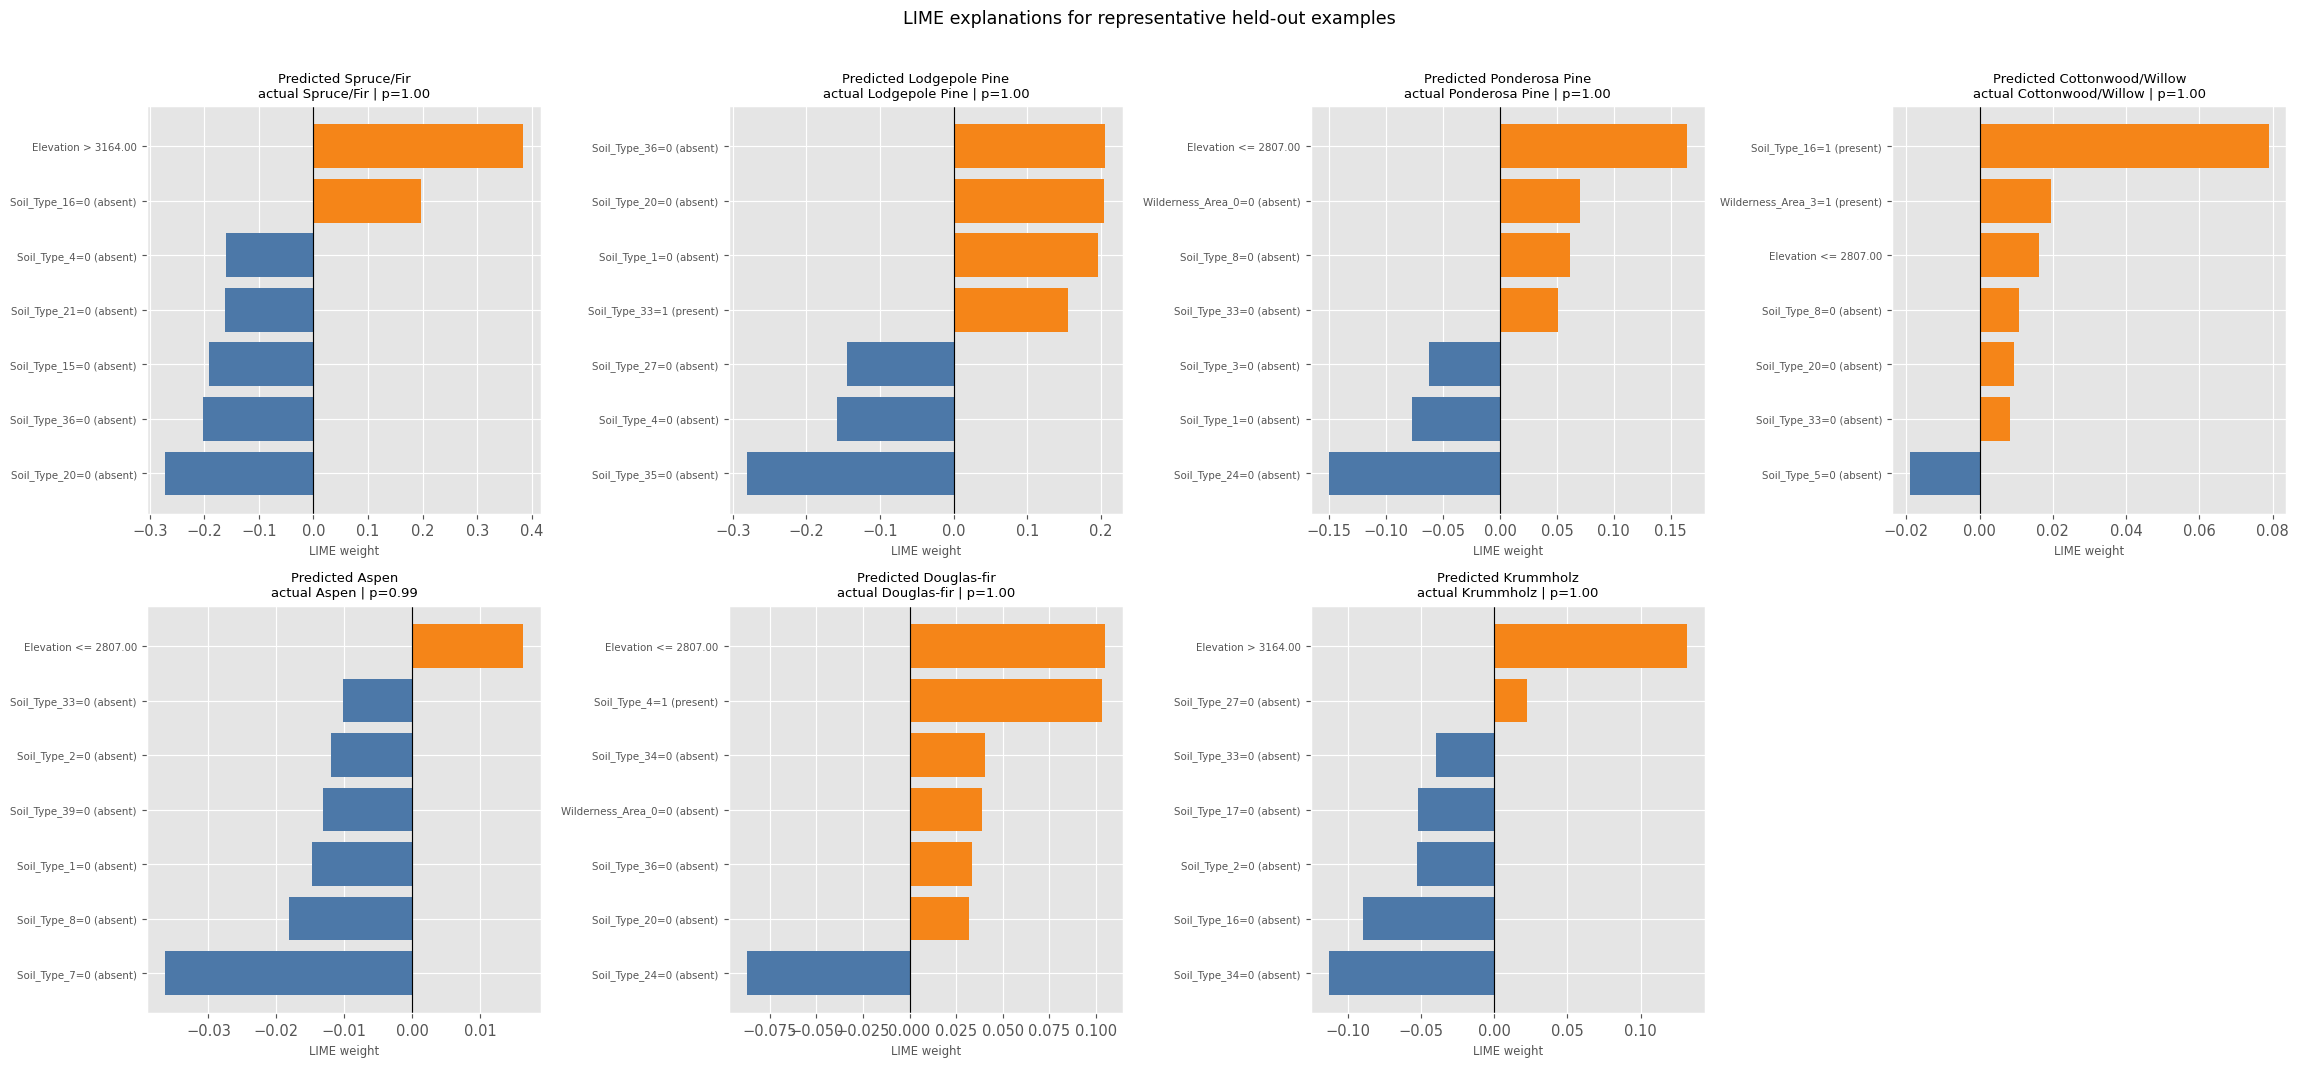

In [29]:
representatives = []
for class_id in range(len(class_names)):
    candidates = np.flatnonzero(y_pred == class_id)
    if len(candidates):
        pos = int(candidates[np.argmax(y_proba[candidates, class_id])])
        representatives.append((class_id, pos))

fig, axes = plt.subplots(2, 4, figsize=(22, 10), squeeze=False)
for ax, (class_id, pos) in zip(axes.flat, representatives):
    exp = explainer.explain_instance(
        X_test.iloc[pos].to_numpy(), model.predict_proba,
        labels=(class_id,), num_features=7, num_samples=2500
    )
    terms = pd.DataFrame(exp.as_list(label=class_id), columns=["condition", "weight"]).sort_values("weight")
    ax.barh(terms.condition, terms.weight,
            color=["#4C78A8" if w < 0 else "#F58518" for w in terms.weight])
    ax.axvline(0, color="black", linewidth=.8)
    ax.set_title(f"Predicted {class_names[class_id]}\nactual {class_names[int(y_test.iloc[pos])]} | p={y_proba[pos, class_id]:.2f}", fontsize=9)
    ax.set_xlabel("LIME weight", fontsize=8)
    ax.tick_params(axis="y", labelsize=7)
for ax in axes.flat[len(representatives):]:
    ax.axis("off")
fig.suptitle("LIME explanations for representative held-out examples", y=1.01)
plt.tight_layout()
plt.show()


## 8. Look at LIME’s local fit scores

LIME’s R² score describes how well its simple surrogate matches XGBoost’s outputs on the generated neighborhood around an observation. We sample test cases and explain the same target class to make scores more comparable. This is not XGBoost’s test accuracy and it does not measure global explanation correctness.


Mean local fit R²: 0.179; standard deviation: 0.118


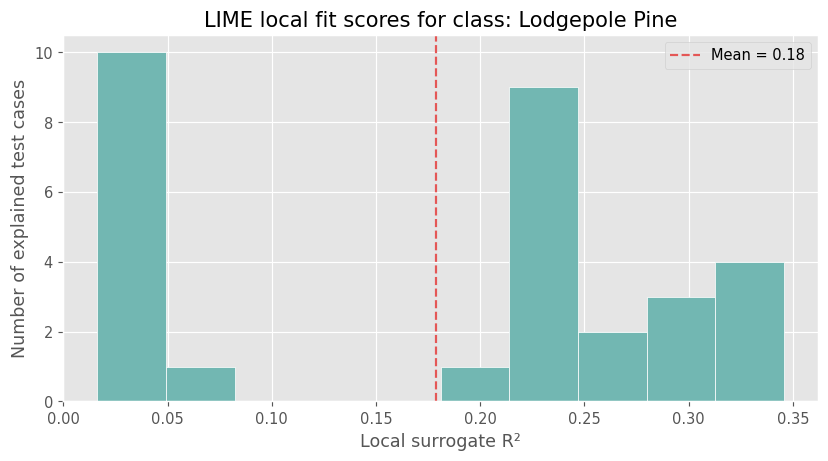

In [31]:
target_class = predicted_class
rng = np.random.default_rng(RANDOM_STATE)
positions = rng.choice(len(X_test), size=min(30, len(X_test)), replace=False)
local_scores = []
for pos in positions:
    exp = explainer.explain_instance(
        X_test.iloc[pos].to_numpy(), model.predict_proba,
        labels=(target_class,), num_features=10, num_samples=2000
    )
    local_scores.append(exp.score)

plt.figure(figsize=(8, 4.5))
plt.hist(local_scores, bins=10, color="#72B7B2", edgecolor="white")
plt.axvline(np.mean(local_scores), color="#E45756", linestyle="--", label=f"Mean = {np.mean(local_scores):.2f}")
plt.xlabel("Local surrogate R²")
plt.ylabel("Number of explained test cases")
plt.title(f"LIME local fit scores for class: {class_names[target_class]}")
plt.legend()
plt.tight_layout()
plt.show()
print(f"Mean local fit R²: {np.mean(local_scores):.3f}; standard deviation: {np.std(local_scores):.3f}")


## 9. Findings and short report

Run all cells, then summarize the outputs below. Keep model performance separate from LIME’s explanation fit.

### Dataset and objective

The original Covertype dataset contains 581,012 forest cells, 54 cartographic features, and seven cover types. This notebook uses a stratified sample of 30,000 rows to keep model fitting practical. The objective is to predict cover type from elevation, terrain, hydrology, access, hillshade, wilderness-area, and soil-type variables.

### Model and general performance

With the fixed stratified 30,000-row sample, five-fold cross-validation accuracy averaged **0.829 ± 0.006**. On the held-out test set, accuracy was **0.839 (6,296/7,500 correct)**; macro F1 was **0.782** and weighted F1 was **0.838**. Review the class-wise table and confusion matrix below to see which cover types have weaker recall and which labels are confused. A baseline that always predicts the test set’s most common class (Lodgepole Pine) would score **48.8%** accuracy, so XGBoost is substantially better overall. However, minority-class performance is uneven: Aspen recall is **0.423** (F1 **0.584**) and Douglas-fir recall is **0.638** (F1 **0.692**), while Lodgepole Pine and Krummholz have F1 scores of **0.861** and **0.868**. The very small Cottonwood/Willow support (36 test rows) makes its metrics especially uncertain. These scores apply to this sampled dataset and split.

### LIME findings

For held-out row position 4915, the actual cover type was **Lodgepole Pine** and XGBoost predicted **Lodgepole Pine** with probability **0.999**. The strongest positive LIME conditions were `Soil_Type_33=1 (present)` (+0.301), `Soil_Type_34=0 (absent)` (+0.284), `Soil_Type_13=0 (absent)` (+0.275); all ten displayed feature weights were positive, so the explanation showed supporting conditions but no negative conditions among its top ten features. The local surrogate R² was **0.017**. Across 30 sampled test cases for the same target class, mean local R² was **0.179 ± 0.118**. This score describes LIME’s local approximation of XGBoost, not classifier accuracy. Since the selected local R² is very low and the mean is also low, the feature weights should be treated as tentative; this run does not show a strong local surrogate match.

### Limitations

The modeling results are from a 30,000-row sample and one fixed stratified split. They estimate performance for data sampled in this way, not necessarily for every forest region. The original dataset has class imbalance, and LIME explanations depend on the selected row and perturbation settings. The 44 binary area/soil features may also be correlated or mutually constrained, so perturbed combinations may not always represent realistic terrain.


## Dataset and objective
Covertype contains 581,012 forest cells, each representing a 30 × 30 metre area. The objective is to predict its forest cover type. The notebook uses a stratified 30,000-row sample to keep the analysis practical.
Its 54 features describe elevation, terrain, distance to water, roads and fire points, hillshade, and wilderness and soil types. The first ten are continuous measurements; the remaining 44 are binary indicators for four wilderness areas and 40 soil types.

## Findings
XGBoost achieved 82.9% ± 0.6% accuracy across five cross-validation folds and 83.9% accuracy on the held-out test set (6,296 of 7,500 correct). Its macro F1 was 0.782. For context, always predicting the most common test class would score 48.8%.
Performance differed by cover type: Aspen recall was 0.423, and Douglas-fir recall was 0.638. Aspen’s low recall means the model missed many Aspen examples, despite its high overall accuracy.
LIME explained one correctly predicted Lodgepole Pine example with probability 0.999. However, its local surrogate R² was just 0.017; the mean across 30 examples was 0.179 ± 0.118. That’s a weak match between LIME’s simple explanation model and XGBoost, so treat the listed feature weights as tentative rather than a reliable account of those predictions.